# Medical Image Processing and Machine Learning

### VU 193.215 - 2026 Summer Term

**Due**: 20.05.2026, 23:59 (CET) - one submission per team via TUWEL

**Mandatory group interviews**: 29.05.2026, 09:00-13:30 (20 min slots)

### Structure 
Before submitting, ensure you have followed these formatting requirements:
- **This notebook:** Contains code only (no theory/text answers).
- **PDF-Report:** Contains all theoretical answers **from the exercise sheet** (not included in this notebook) and data interpretations. Please add the corresponding (sub-) task number for each interpretation/answer in the PDF report.


---

## Assignment 1

The aim of the first assignment is to get familiar with **Python**, the implementation of **Principal Component Analysis (PCA)**, and the investigation of its characteristics. Parts of the code (data, plot functions) are provided so that students can focus on the main topics of the assignment.

---

#### Helper Functions in helper_functions.py

- `get_data()` loads all the neccecary variables that you will be working on
- `plot2DPCA()` and `plot3DPCA()` can be used to plot:
  - Data points
  - Eigenvectors & Eigenvalues
  - Ellipses & ellipsoids
  - Reconstructed data
- `plotDemo()` demonstrates their usage.

### Import necessary libraries and functions for this assignment

In [1]:
from helper_functions import plot2DPCA, plot3DPCA, get_data, plotDemo
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniconda/base/envs/pca-env/bin/python


# Demo

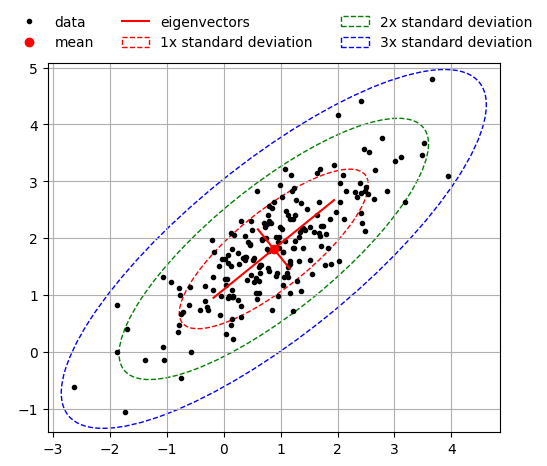

In [3]:
plotDemo()

### Load the data used in this assignment

In [4]:
#load data using helper function
data0, data1, data2, data3d, bones = get_data()

data0 shape: (200, 2)
data1 shape: (200, 2)
data2 shape: (200, 2)
data3d shape: (1000, 3)
bones shape: (128, 2, 14)


# Tasks

#### In this exercise, data points are given in a d × n-Matrix X, where n denotes the number of points and their dimensionality, i.e. 2 × n  for a set of 2D points (data0, data1, data2) and 3 × n for points in 3D (data3d).

## 1. Covariance Matrix

### (a) Implement a function `ourCov(X)` that computes the population-based covariance matrix `C` from a data matrix `X`. (3 Points)

- You are **not allowed** to use any built-in function that directly computes the population-based covariance matrix (such as `np.cov`).
- You **may use** basic NumPy operations such as `mean`, matrix multiplication, and `transpose`.
- After implementing `ourCov(X)`, **compare** its output to the result of `np.cov`.
  - **Note:** `np.cov` expects a matrix of shape **d × n** (n_features × n_samples), so you may need to transpose your input before using it.

In [5]:
def ourCov(X):
    """
    Computes the covariance matrix of the input data X.

    Parameters:
        X (numpy.ndarray): Input data of shape (n_samples, n_features)

    Returns:
        C (numpy.ndarray): Covariance matrix
    """
    
    # TODO: Get number of samples
    n = X.shape[0]

    # TODO: Compute the mean vector
    # axis = 0 --> calculates the mean across each column
    mean_vector = np.mean(X, axis=0)

    # TODO: Center the data
    X_centered = X - mean_vector

    # TODO: Compute the population-based covariance matrix
    C = np.dot(X_centered.T, X_centered) / n

    return C

In [6]:
for data in [data0, data1, data2]:

    print('ourCov')
    print(ourCov(data), '\n\n')

    print('np.cov')
    print(np.cov(data.T, bias=True), '\n\n')

ourCov
[[0.93332559 0.6733484 ]
 [0.6733484  1.03043861]] 


np.cov
[[0.93332559 0.6733484 ]
 [0.6733484  1.03043861]] 


ourCov
[[ 0.92409773 -0.90379557]
 [-0.90379557  0.98640071]] 


np.cov
[[ 0.92409773 -0.90379557]
 [-0.90379557  0.98640071]] 


ourCov
[[0.88323459 0.01665492]
 [0.01665492 1.00098475]] 


np.cov
[[0.88323459 0.01665492]
 [0.01665492 1.00098475]] 




### (b) Compute the covariance matrix `C` for all data matrices (`data0`, `data1`, `data2`). (3 Points)

- Visualize each dataset using `plt.scatter()` in **separate figures**.
- Set the axis scale to equal using `plt.axis('equal')`.

 Covariance Matrix C for Data0
 [[0.93332559 0.6733484 ]
 [0.6733484  1.03043861]]


<Figure size 500x500 with 0 Axes>

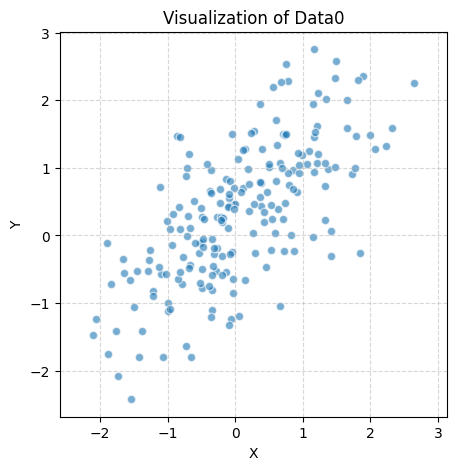

 Covariance Matrix C for Data1
 [[ 0.92409773 -0.90379557]
 [-0.90379557  0.98640071]]


<Figure size 500x500 with 0 Axes>

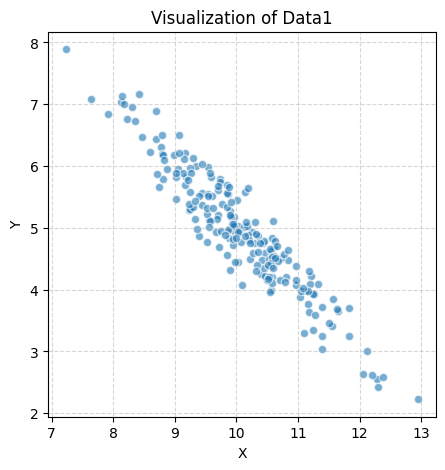

 Covariance Matrix C for Data2
 [[0.88323459 0.01665492]
 [0.01665492 1.00098475]]


<Figure size 500x500 with 0 Axes>

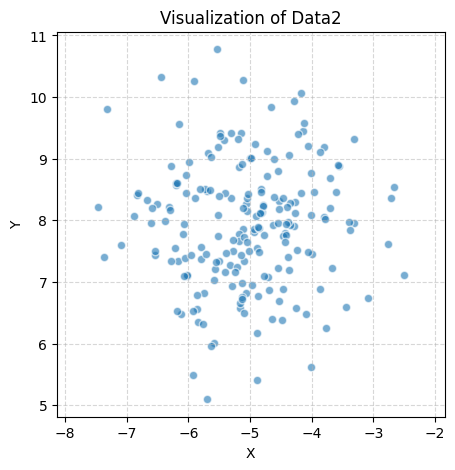

In [7]:
import matplotlib.pyplot as plt

for i, data in enumerate([data0, data1, data2], start=1):
    
    fig = plt.figure(figsize=(5, 5))

    # TODO: Compute and print the covariance matrix
    C = ourCov(data)
    print(f" Covariance Matrix C for Data{i-1}\n {C}")
    
    # TODO: Plot the data
    fig = plt.figure(figsize=(5, 5))
    plt.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='w')
    plt.title(f"Visualization of Data{i-1}")
    plt.xlabel("X")
    plt.ylabel("Y")
    
    
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2. PCA

### (a) Implement a function `pca(X, n_components)` that performs Principal Component Analysis (PCA) on a data matrix `X`. (3 Points)

- The implementation must work for data of **any dimensionality** (i.e., arbitrary number of features).
- The function should return:
  - The **Eigenvalues**, sorted in **descending order**.
  - The corresponding **normalized Eigenvectors**, sorted according to their eigenvalues.
- You may use NumPy’s `np.linalg.eig()` function to compute eigenvalues and eigenvectors.

In [8]:
def pca(X, n_components=None):
    """
    Perform Principal Component Analysis (PCA) on the input data matrix X.

    Parameters:
        X (numpy.ndarray): Input data of shape (n_samples, n_features)
        n_components (int or None): Number of principal components to retain. If 'None' retain all

    Returns:
        X_reduced (numpy.ndarray): Projected data
        eigvecs_reduced (numpy.ndarray): Selected eigenvectors
        eigvals_selected (numpy.ndarray): Selected eigenvalues
        mean (numpy.ndarray): Mean used for centering
    """

    # TODO: Center the data
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # TODO: Compute the covariance matrix
    n = X.shape[0]
    C = np.dot(X_centered.T, X_centered) / n 

    # TODO: Compute eigenvalues and eigenvectors
    eigvalues, eigvectors = np.linalg.eigh(C)

    # TODO: Sort eigenvalues and eigenvectors in descending order
    # [::-1] --> reverses the array; 
    idx = np.argsort(eigvalues)[::-1]   # could also do idx = np.argsort(-eigvals) instead
    sorted_eigenvalues = eigvalues[idx]
    sorted_eigvectors = eigvectors[:, idx]

    # TODO: Select the top n_components
    if n_components is None:
        n_components = X.shape[1]
    
    eigvals_selected = sorted_eigenvalues[:n_components]
    eigvecs_reduced = sorted_eigvectors[:, :n_components]

    # TODO: Project data onto principal components 
    # used @ instead of np.dot()
    X_reduced = X_centered @ eigvecs_reduced  

    return X_reduced, eigvecs_reduced, eigvals_selected, mean

### (b) Use plot2DPCA to plot results for all matrices (data0, data1, data2) (2 Points)

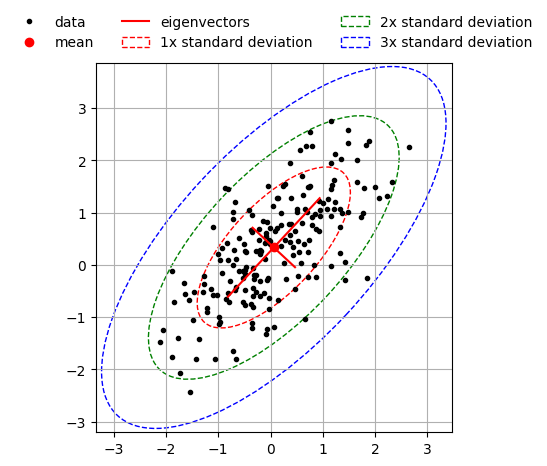

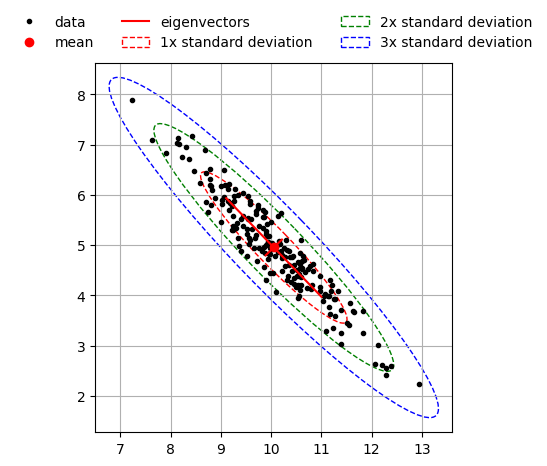

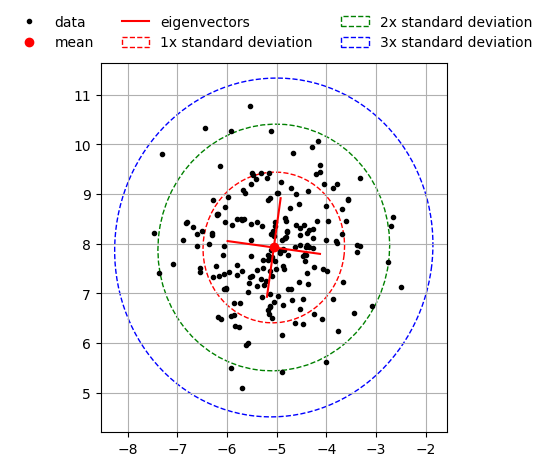

In [9]:
for data in [data0, data1, data2]:

    # TODO: Perform PCA
    X_reduced, eigVec, eigVal, mean = pca(data, n_components=None)
    
    # Plot using the plot2DPCA function
    plot2DPCA(
        data=data,
        mju=mean,
        eigVec=eigVec,
        eigVal=eigVal,
        showStd=True,
    )

## 3. Subspace projection

### (a) PCA Projection and Reconstruction on 2D Data

#### First step: **(2 Points)**
- Perform **PCA** on `data1`.
- Project the data onto the **first principal component** (main vector).
- **Plot** the projected data.

#### Second step: **(3 Points)**
- Reconstruct the data from the projection back into the original 2D space.
- Plot the reconstructed data alongside the original data using `plot2DPCA()`.
- Compute the **average reconstruction error** (e.g., mean squared error between original and reconstructed points).

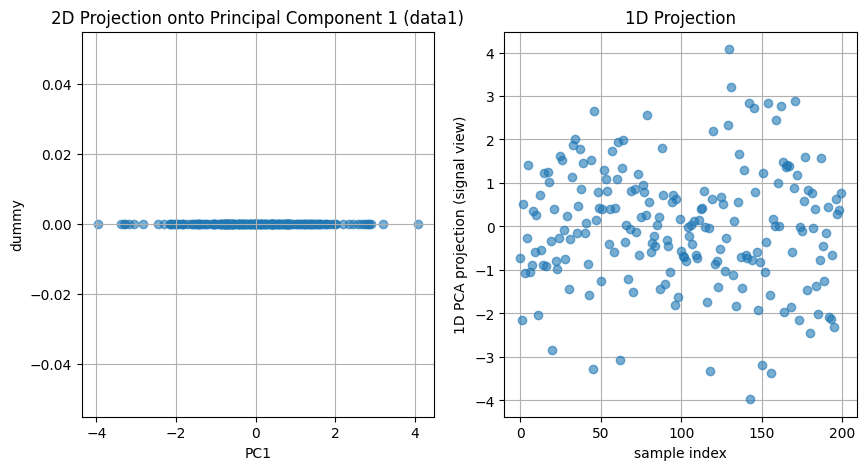

Shape after projection (data1) (200, 1)


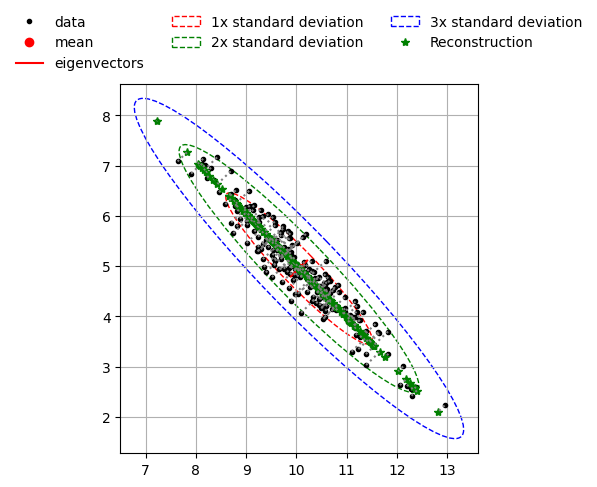

Average reconstruction error for data1: 0.0255


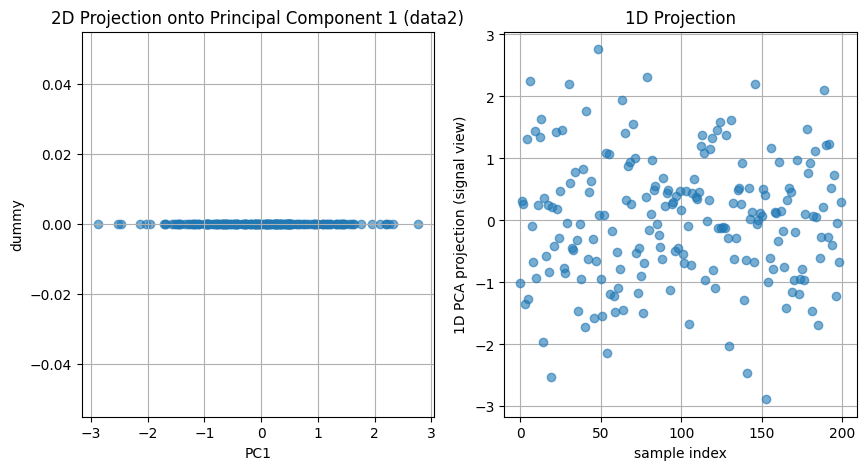

Shape after projection (data2): (200, 1)


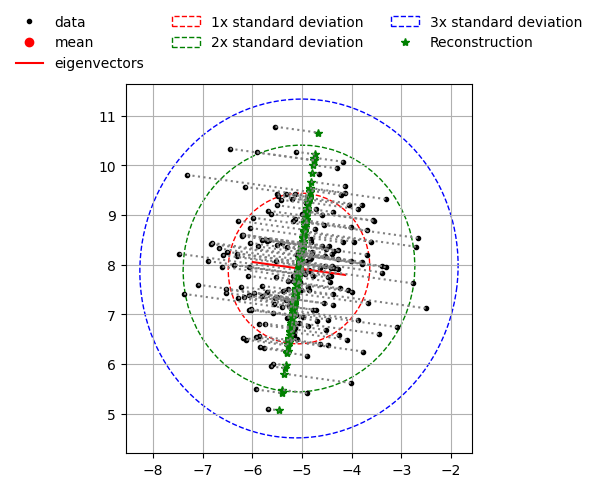

Average reconstruction error for data2: 0.4405


In [10]:
# TODO: Apply PCA and project to first component
X_proj_full,eigenVectors,eigenValues,mean=pca(data1, n_components=None) # i.
X_proj =X_proj_full[:,[0]] #reduction from 2D to 1D, ii.

# TODO: Visualize projection
def plot_projection(X_proj, title):
    fig, (ax2D, ax1D) = plt.subplots(1, 2,figsize=(10,5))

    ax2D.scatter(X_proj[:,0],np.zeros_like(X_proj[:,0]),alpha=0.6) # 2D dummy-axis plot
    ax2D.set_title(f"2D Projection onto Principal Component 1 ({title})")
    ax2D.set_xlabel("PC1")
    ax2D.set_ylabel("dummy")
    ax2D.grid(True)
    
    ax1D.plot(X_proj[:,0],'o',alpha=0.6) # 1D signal plot
    ax1D.set_title("1D Projection")
    ax1D.set_xlabel("sample index")
    ax1D.set_ylabel("1D PCA projection (signal view)")
    ax1D.grid(True)
    plt.show()
    
plot_projection(X_proj, "data1")

# TODO: Print the shape of the projected data
print("Shape after projection (data1)", X_proj.shape) # iv., slide 41

# TODO: Reconstruct from projection
pc1_data1=eigenVectors[:,[0]] # v.
X_reconstructed=X_proj @ pc1_data1.T + mean # slide 44

# TODO: Plot reconstruction and compare to original
plot2DPCA(data=data1, mju=mean, eigVec=eigenVectors, eigVal=eigenValues, showStd=1,recData=X_reconstructed,showReconstruction=1) # vi.

# TODO: Compute reconstruction error and print it
reconstruction_error_data1=np.mean((data1-X_reconstructed) ** 2) # viii.
print(f"Average reconstruction error for data1: {reconstruction_error_data1:.4f}")

# TODO : Repeat for data2 and compare results
X_proj_full2,eigenVectors2,eigenValues2,mean2=pca(data2, n_components=None)
X_proj2=X_proj_full2[:,[0]]

plot_projection(X_proj2, "data2")

print("Shape after projection (data2):",X_proj2.shape)

pc1_data2=eigenVectors2[:,[0]]
X_reconstructed2=X_proj2 @pc1_data2.T+mean2 #slide 44

plot2DPCA(data=data2, mju= mean2, eigVec=eigenVectors2, eigVal=eigenValues2, showStd=1, recData=X_reconstructed2,showReconstruction=1)

reconstruction_error_data2=np.mean((data2-X_reconstructed2) ** 2) # ix.
print(f"Average reconstruction error for data2: {reconstruction_error_data2:.4f}")

### (b) Reconstruction Using the Second Principal Component (2 Points)

- Repeat the steps from (a), but this time project the data onto the **second principal component** (side vector).
- Reconstruct the data and analyze the results in the report.

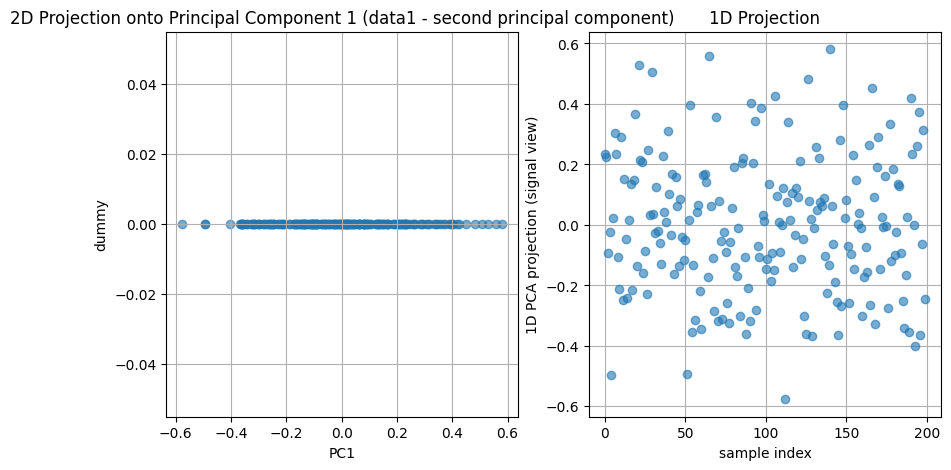

Shape after projection onto PC2 (data1): (200, 1)


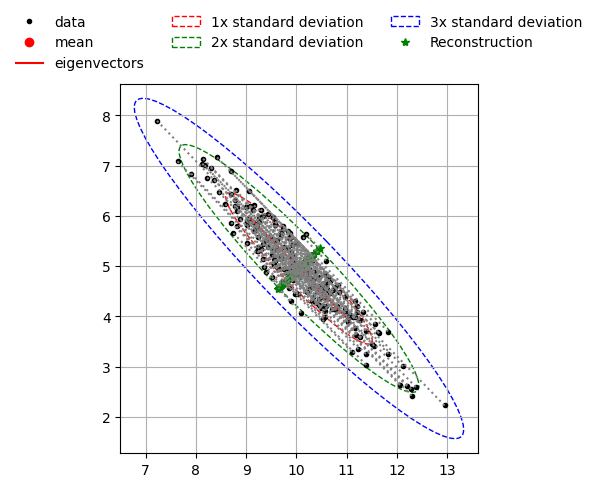

Average reconstruction error for data1 using PC2: 0.9298


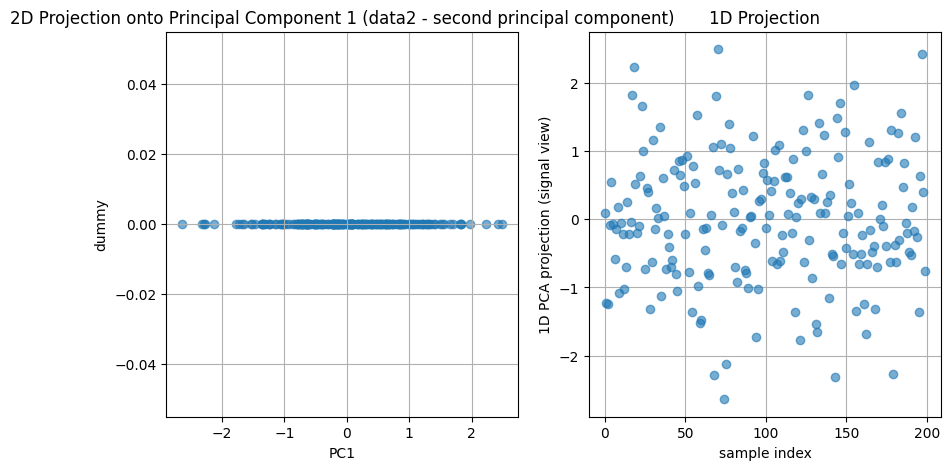

Shape after projection onto PC2 (data2): (200, 1)


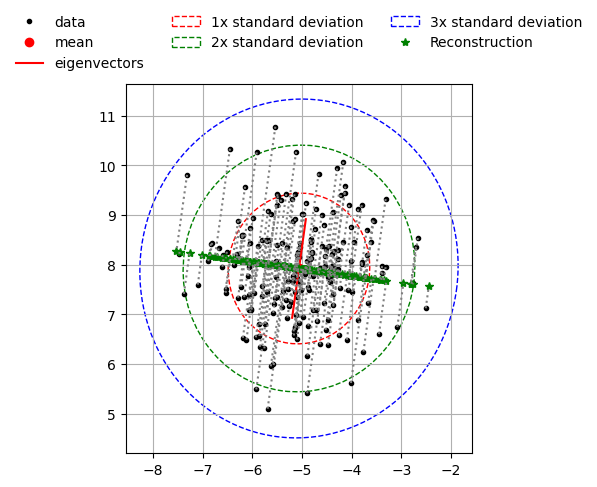

Average reconstruction error for data2 using PC2: 0.5016


In [11]:
# TODO: Reconstruct from projection

# Project data1 onto the second principal component
X_proj_full_second, eigenVectors_second, eigenValues_second, mean_second = pca(data1, n_components=None)
X_proj_second = X_proj_full_second[:, [1]]

plot_projection(X_proj_second, "data1 - second principal component")
print("Shape after projection onto PC2 (data1):", X_proj_second.shape)

# Reconstruct from the second principal component only
pc2_data1 = eigenVectors_second[:, [1]]
X_reconstructed_second = X_proj_second @ pc2_data1.T + mean_second



# Plot reconstruction and compare to original
plot2DPCA(
    data=data1,
    mju=mean_second,
    eigVec=eigenVectors_second,
    eigVal=eigenValues_second,
    showStd=1,
    recData=X_reconstructed_second,
    showReconstruction=1,
)

# Compute reconstruction error
reconstruction_error_second_component = np.mean((data1 - X_reconstructed_second) ** 2)
print(f"Average reconstruction error for data1 using PC2: {reconstruction_error_second_component:.4f}")

# Repeat for data2 for comparison with 3a
X_proj_full_second2, eigenVectors_second2, eigenValues_second2, mean_second2 = pca(data2, n_components=None)
X_proj_second2 = X_proj_full_second2[:, [1]]

plot_projection(X_proj_second2, "data2 - second principal component")
print("Shape after projection onto PC2 (data2):", X_proj_second2.shape)

pc2_data2 = eigenVectors_second2[:, [1]]
X_reconstructed_second2 = X_proj_second2 @ pc2_data2.T + mean_second2

plot2DPCA(
    data=data2,
    mju=mean_second2,
    eigVec=eigenVectors_second2,
    eigVal=eigenValues_second2,
    showStd=1,
    recData=X_reconstructed_second2,
    showReconstruction=1,
)

reconstruction_error_second_component2 = np.mean((data2 - X_reconstructed_second2) ** 2)
print(f"Average reconstruction error for data2 using PC2: {reconstruction_error_second_component2:.4f}")


## 4. Investigation in 3D

### (a) PCA and 3D Visualization (3 Points)
- Perform **PCA** on the `data3d`.
- Plot the original data points in **3D** using `plot3DPCA()`, along with the **Eigenvectors** of the covariance matrix.

In [12]:
# Print covariance matrix
C_3d = ourCov(data3d)
print("Covariance Matrix C for data3d:")
print(C_3d)

# Apply PCA to 3D data
X_reduced_3d, eigVec_3d, eigVal_3d, mean_3d = pca(data3d, n_components=None)

print("Eigenvalues for data3d:", eigVal_3d)
print("Eigenvectors shape:", eigVec_3d.shape)

# Plot using the plot3DPCA function
plot3DPCA(
    data=data3d,
    mju=mean_3d,
    eigVec=eigVec_3d,
    eigVal=eigVal_3d,
)


Covariance Matrix C for data3d:
[[1.0283333  0.79057057 0.53796048]
 [0.79057057 1.45223227 0.33548043]
 [0.53796048 0.33548043 1.00850134]]
Eigenvalues for data3d: [2.33064347 0.8385882  0.31983523]
Eigenvectors shape: (3, 3)


/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: overflow encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced




### (b) Projection and Reconstruction in Subspace (2 Points)

- Project the data onto the subspace spanned by the **first two principal components** (i.e., the top 2 Eigenvectors).
- What is the **dimensionality** of the data after projection?
- Reconstruct the data from the 2D projection back into the original **3D** space.
- Plot both the **original** and the **reconstructed** data in 3D using `plot3DPCA()`.

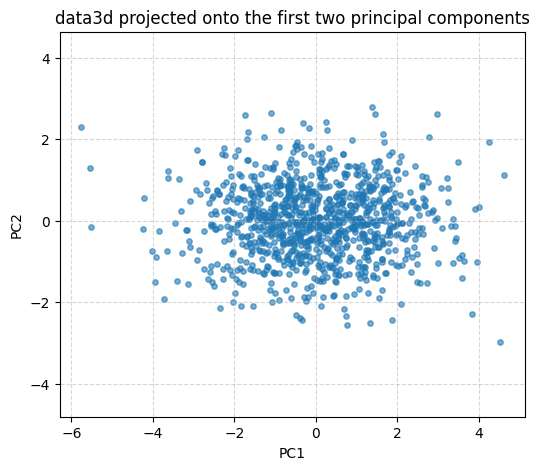

Dimensionality after projection: (1000, 2)
Average reconstruction error for data3d using first two PCs: 0.1066


In [13]:
# Project data3d to the first two principal components
X_reduced_3d_2, eigVec_3d_2, eigVal_3d_2, mean_3d_2 = pca(data3d, n_components=2)

# Plot the 2D subspace coordinates
plt.figure(figsize=(6, 5))
plt.scatter(X_reduced_3d_2[:, 0], X_reduced_3d_2[:, 1], alpha=0.6, s=15)
plt.title("data3d projected onto the first two principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Print dimensionality of X_reduced
print("Dimensionality after projection:", X_reduced_3d_2.shape)

# Reconstruct from projection into 3D
X_reconstructed_3d = X_reduced_3d_2 @ eigVec_3d_2.T + mean_3d_2
reconstruction_error_3d = np.mean((data3d - X_reconstructed_3d) ** 2)
print(f"Average reconstruction error for data3d using first two PCs: {reconstruction_error_3d:.4f}")

# Plot reconstruction using plot3DPCA
plot3DPCA(
    data=data3d,
    mju=mean_3d_2,
    eigVec=eigVec_3d,
    eigVal=eigVal_3d,
    recData=X_reconstructed_3d,
    showReconstruction=True,
)


## 5. Shape Modeling

### (a) Data Exploration (2 Points)

- The variable `bones` has shape **(nPoints, nDimensions, nShapes)**.
- Visualize all bone shapes:
  - Use `plt.scatter` to plot **each shape** in **black** with transparency (`alpha=0.5`).
  - Compute and overlay the **mean shape** in **red**.
- Ensure all bones are plotted in a **single figure** for comparison.

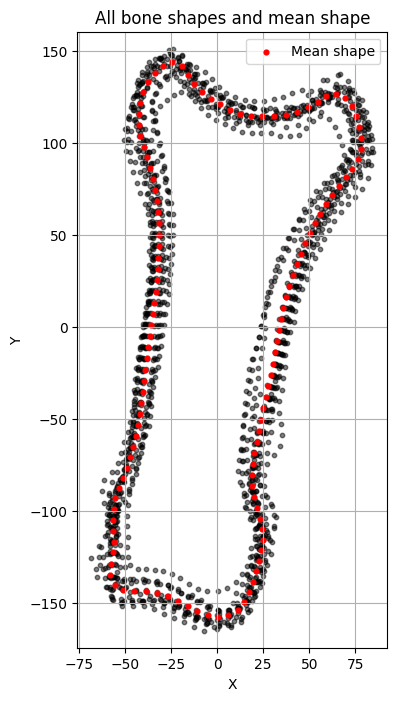

In [14]:
fig = plt.figure(figsize=(4, 8))

# TODO: Compute mean shape
mean_shape = np.mean(bones, axis=2)


# TODO: Plot all bone shapes into a single plot
for i in range(bones.shape[2]):
    shape = bones[:, :, i]
    plt.scatter(shape[:, 0], shape[:, 1], c="black", alpha=0.5, s=10)


# TODO: Plot mean shape in red in the sample plot as all other bones
plt.scatter(mean_shape[:, 0], mean_shape[:, 1], c="red", s=12, label="Mean shape")

plt.title("All bone shapes and mean shape")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

### (b) Principal Component Analysis (PCA) (2 Points)

- Reshape the 3D shape array `bones` into a 2D matrix of shape **(nShapes, nPoints × nDimensions)**.
- Perform **PCA** on this reshaped matrix to obtain **(2 Points)**:
  - **Eigenvectors** (principal directions)
  - **Eigenvalues** (variances)
  - **Mean shape**
- Implement a function `generate_shape(b, mean_shape, eigVec)` **(3 Points)**:
  - `b` is a coefficient vector (length = number of modes used).
  - Generate a shape by linearly combining the mean shape and a subset of eigenvectors.
  - Reshape the output `new_shape` back to shape **(nPoints, nDimensions)** for plotting.

  - Set `b = [100, 100]` and plot the newly generated shape and the mean shape together in one plot

In [15]:
# TODO: Reshape bones to 2D matrix for PCA (nShapes, nPoints * nDimensions) 
nPoints, nDimensions, nShapes = bones.shape

bones_reshaped = bones.transpose(2, 0, 1).reshape(nShapes, nPoints * nDimensions)

print("Original bones shape:", bones.shape)
print("Reshaped bones matrix shape:", bones_reshaped.shape)

# TODO: Apply PCA 

X_reduced_bones, eigVec_bones, eigVal_bones, mean_shape_flat = pca(bones_reshaped, n_components=None)

print("Eigenvectors shape:", eigVec_bones.shape)
print("Eigenvalues shape:", eigVal_bones.shape)
print("Mean shape flat shape:", mean_shape_flat.shape)
mean_shape_pca = mean_shape_flat.reshape(nPoints, nDimensions)

print("Mean shape shape:", mean_shape_pca.shape)


Original bones shape: (128, 2, 14)
Reshaped bones matrix shape: (14, 256)
Eigenvectors shape: (256, 256)
Eigenvalues shape: (256,)
Mean shape flat shape: (256,)
Mean shape shape: (128, 2)


/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: overflow encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced


### (c) Implement a function `generate_shape(b, mean_shape, eigVec)` (3 Points):
- `b` is a coefficient vector (length = number of modes used).
- Generate a shape by linearly combining the mean shape and a subset of Eigenvectors:
    ```
    new_shape = mean_shape + b @ eigVec[:len(b), :]
    ```
- Reshape the output `new_shape` back to shape **(nPoints, nDimensions)** for plotting.
- Set `b = [100, 100]` and plot the newly generated shape and the mean shape together in one plot

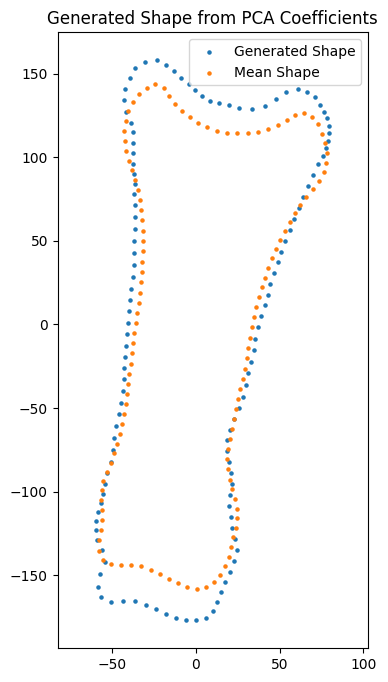

In [16]:
# TODO: Implement generate_shape function 
def generate_shape(b, mean_shape, eigVec):
    """
    Generate a new shape using PCA coefficients.

    Parameters:
        b (np.ndarray): Coefficient vector (1D), shape (n_components,)
        mean_shape (np.ndarray): Flattened mean shape, shape (n_features,)
        eigVec (np.ndarray): PCA eigenvectors, shape (n_features, n_features)

    Returns:
        new_shape (np.ndarray): Generated shape reshaped to (nPoints, nDimensions)
    """

    # TODO: Ensure b is a row vector
    b = np.asarray(b)
    selected_eigVec = eigVec[:, :len(b)]


    # TODO: Linearly combine mean with first len(b) eigenvectors
    new_shape_flat = (mean_shape + selected_eigVec @ b).real

    # TODO: Reshape back to (nPoints, nDimensions)
    new_shape = new_shape_flat.reshape(nPoints, nDimensions)

    return new_shape

# TODO: Generate and plot a shape for testing 
b = [100, 100]  
generated = generate_shape(b, mean_shape_flat, eigVec_bones)

# TODO: Plot generated shape and mean shape for comparison in one plot
plt.figure(figsize=(4, 8))
plt.scatter(generated[:, 0], generated[:, 1], label="Generated Shape", s=5)
plt.scatter(mean_shape_pca[:, 0], mean_shape_pca[:, 1], label="Mean Shape", s=5)
plt.axis("equal")
plt.title("Generated Shape from PCA Coefficients")
plt.legend()
plt.show()

### (d) Visualize Variation Along a Single PCA Mode (4 Points)

- Write a function `visualize_shape_mode(bones, mode, num_samples=10)` that:
  1. Reshapes the 3D shape array `bones` into 2D shape for PCA: `(nShapes, nPoints * nDimensions)`.
  2. Applies PCA to extract Eigenvectors, Eigenvalues, and the mean shape.
  3. Plots:
     - The **mean shape** in red.
     - A series of generated shapes by varying the specified PCA mode in the range **±3λ**, where λ is the standard deviation (square root of the Eigenvalue) for the selected mode.
- The shapes should be plotted as transparent black points (`alpha=0.5`) in a single figure to visualize the effect of that mode together with the mean shape.
- Use `generate_shape()` internally to create shapes.

/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: overflow encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced


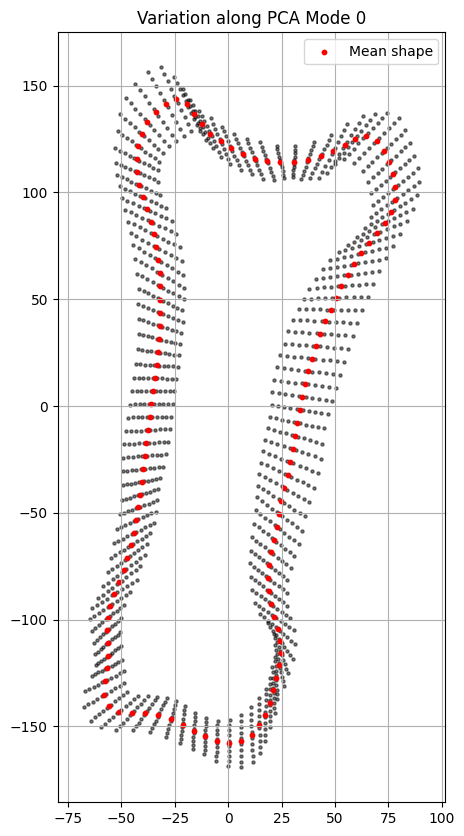

In [17]:
def visualize_shape_mode(bones, mode=0, num_samples=10):
    """
    Visualize variation along a specific PCA mode using shape data.

    Parameters:
        bones (np.ndarray): 3D shape array of shape (nPoints, nDimensions, nShapes)
        mode (int): Index of the PCA mode to vary
        num_samples (int): Number of samples to generate in [-3λ, 3λ] range
    """
    # TODO: Reshape bones to 2D matrix for PCA
    nPoints, nDimensions, nShapes = bones.shape
    bones_reshaped = bones.transpose(2, 0, 1).reshape(nShapes, nPoints * nDimensions)


    # TODO: Apply PCA
    _, eigVec, eigVal, mean_shape = pca(bones_reshaped, n_components=None)

    # Avoiding complex-value warnings from numerical eigendecomposition
    eigVec = eigVec.real
    eigVal = eigVal.real
    mean_shape = mean_shape.real

    # Standard deviation for selected mode
    std = np.sqrt(eigVal[mode])

    # TODO: Prepare plot and plot mean shape and use generate_shape and plot new shape
    plt.figure(figsize=(5, 10))

    # TODO: Vary the selected mode in ±3λ
    values = np.linspace(-3 * std, 3 * std, num_samples)

    for value in values:
        b = np.zeros(mode + 1)
        b[mode] = value

        new_shape = generate_shape(b, mean_shape, eigVec)

        plt.scatter(
            new_shape[:, 0],
            new_shape[:, 1],
            c="black",
            alpha=0.5,
            s=5
        )

    # Plot mean shape
    mean_shape_2d = mean_shape.reshape(nPoints, nDimensions)

    plt.scatter(
        mean_shape_2d[:, 0],
        mean_shape_2d[:, 1],
        c="red",
        s=10,
        label="Mean shape"
    )


    plt.axis('equal')
    plt.title(f"Variation along PCA Mode {mode}")
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_shape_mode(bones, mode=0, num_samples=10)

/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: overflow encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced


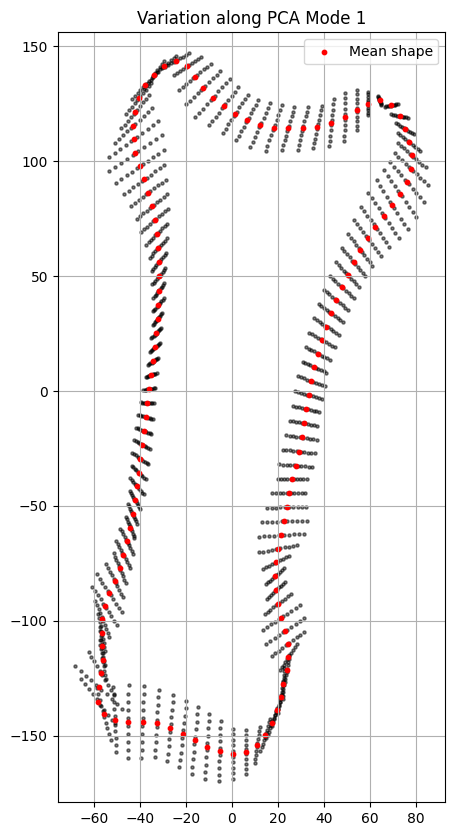

In [18]:
visualize_shape_mode(bones, mode=1, num_samples=10)

/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: overflow encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/1366716171.py:42: RuntimeWarning: invalid value encountered in matmul
  X_reduced = X_centered @ eigvecs_reduced


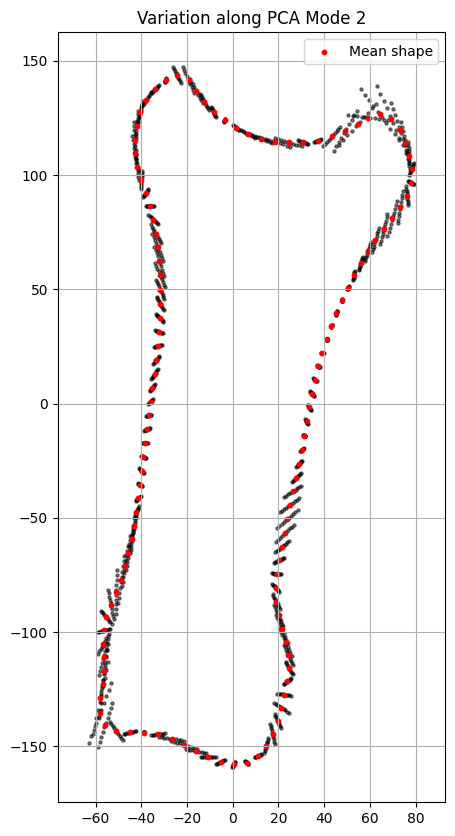

In [19]:
visualize_shape_mode(bones, mode=2, num_samples=10)

### (e) Random Shape Sampling and Variance Thresholding (4 Points)

- Implement a function that generates random shapes from the PCA shape model using a random coefficient vector:

  ```
  b = np.random.randn(1, n_components) * stddevs[:n_components]
  ```

- The number of principal components (i.e., length of `b`) determines how many PCA modes influence the generated shape.

- Your function should:

  1. Compute the **total variance** and **cumulative explained variance** from the PCA eigenvalues.
  2. Determine how many components are needed to reach the following thresholds of total variance:
     - **100%**
     - **95%**
     - **90%**
     - **80%**
  3. For each threshold:
     - Generate a random shape using the corresponding number of PCA components.
     - Plot the generated shape in blue.
     - Overlay the **mean shape** in red for reference.
     - Use `plt.axis('equal')` and `plt.grid(True)` for consistency.
     - Add a title indicating how many components were used and what percentage of variance they capture.

In [20]:
def plot_shape_with_variance_thresholds(bones, eigVec, eigVal, mean_shape, stddevs, thresholds=[1.0, 0.95, 0.90, 0.80]):
    """
    Generate and plot random shapes using PCA components for specific variance thresholds.

    Parameters:
        bones (np.ndarray): Original 3D shape data of shape (nPoints, nDimensions, nShapes)
        eigVec (np.ndarray): PCA eigenvectors (shape: nFeatures x nFeatures)
        eigVal (np.ndarray): PCA eigenvalues
        mean_shape (np.ndarray): Flattened mean shape (1D array of length nFeatures)
        stddevs (np.ndarray): Standard deviations for each PCA mode (sqrt of eigVal)
        thresholds (list): List of variance thresholds to evaluate (default: [1.0, 0.95, 0.90, 0.80])
    """
    # TODO: Calculate total variance and explained variance ratio
    eigVal = eigVal.real
    eigVal = np.maximum(eigVal, 0)

    total_variance = np.sum(eigVal)
    explained_variance_ratio = eigVal / total_variance
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    # TODO: get nPoints, nDimensions, nShapes
    nPoints, nDimensions, nShapes = bones.shape

    eigVec = eigVec.real
    mean_shape = mean_shape.real
    stddevs = stddevs.real

    # TODO: loop over thresholds
    for threshold in thresholds:

        # TODO: Determine number of components required to reach threshold
        if threshold == 1.0:
            n_components = len(eigVal)
        else:
            n_components = np.searchsorted(cumulative_explained_variance, threshold) + 1

        captured_variance = cumulative_explained_variance[n_components - 1]
        
        # TODO: Generate random coefficient vector using stddevs and n_components
        b = np.random.randn(n_components) * stddevs[:n_components]

        # TODO: Generate shape from PCA components using generate_shape function
        generated_shape = generate_shape(b, mean_shape, eigVec)

        mean_shape_2d = mean_shape.reshape(nPoints, nDimensions)

        # TODO: Plot the shape and mean shape
        plt.figure(figsize=(5, 10))

        plt.scatter(
            generated_shape[:, 0],
            generated_shape[:, 1],
            c="blue",
            s=5,
            label="Random generated shape"
        )

        plt.scatter(
            mean_shape_2d[:, 0],
            mean_shape_2d[:, 1],
            c="red",
            s=5,
            label="Mean shape"
        )

        plt.axis("equal")
        plt.grid(True)
        plt.title(
            f"{int(threshold * 100)}% Variance with {n_components} Components\n"
            f"Captured variance: {captured_variance * 100:.2f}%"
        )
        plt.legend()
        
        filename = f"random_shape_{int(threshold * 100)}_variance.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()
    

/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/3609932606.py:21: RuntimeWarning: divide by zero encountered in matmul
  new_shape_flat = (mean_shape + selected_eigVec @ b).real
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/3609932606.py:21: RuntimeWarning: overflow encountered in matmul
  new_shape_flat = (mean_shape + selected_eigVec @ b).real
/var/folders/7y/wgwt8n3n1ss_t788msvzbnl80000gn/T/ipykernel_28467/3609932606.py:21: RuntimeWarning: invalid value encountered in matmul
  new_shape_flat = (mean_shape + selected_eigVec @ b).real


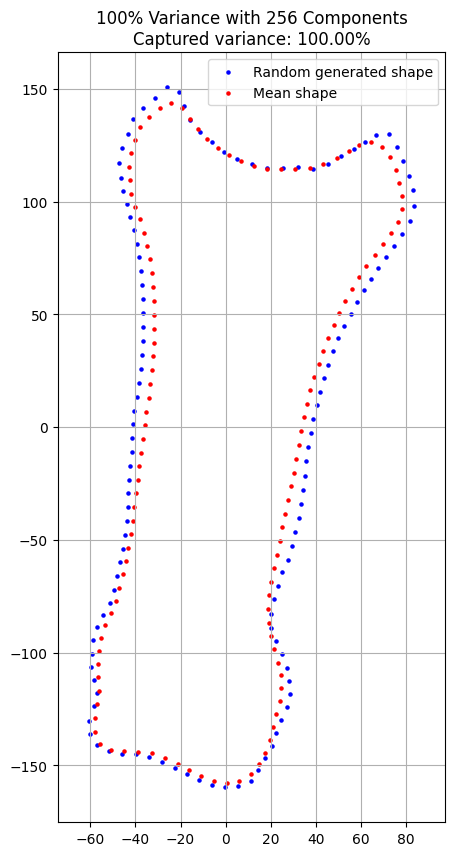

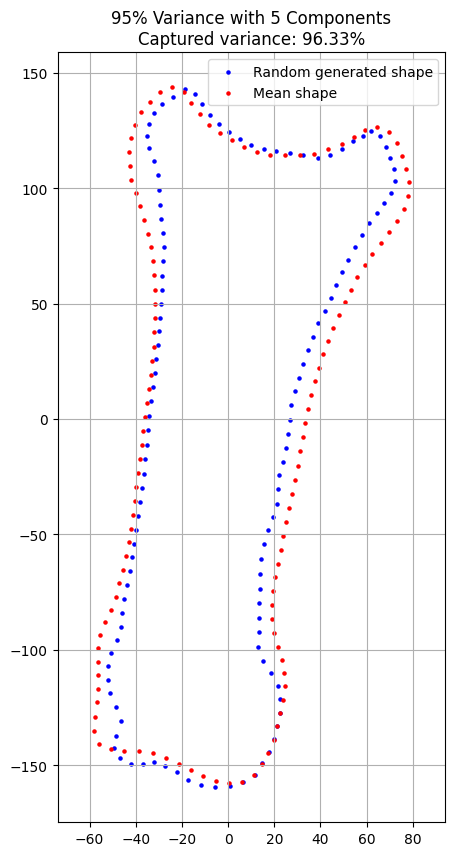

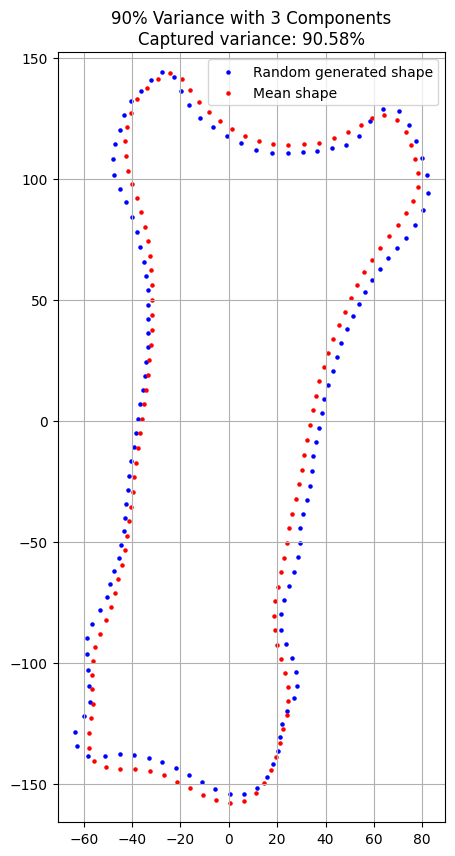

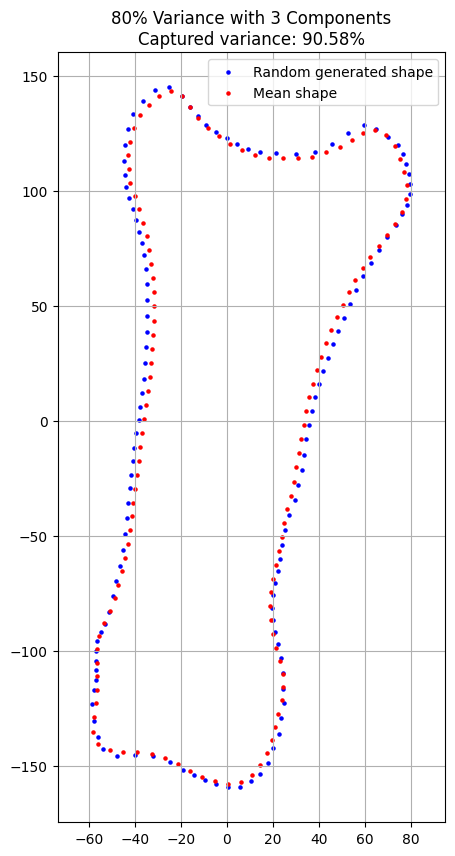

In [21]:
# TODO plot the shapes with variance thresholds

stddevs = np.sqrt(np.maximum(eigVal_bones.real, 0))

# Plot the shapes with variance thresholds
plot_shape_with_variance_thresholds(
    bones,
    eigVec_bones,
    eigVal_bones,
    mean_shape_flat,
    stddevs,
    thresholds=[1.0, 0.95, 0.90, 0.80]
)